In [2]:
%load_ext autoreload
%autoreload 2

import torch
import polars as pl
from sklearn.preprocessing import LabelEncoder, StandardScaler
from gnn_experiments.mogonet_eval import mogonet_eval

# load the best model and evaluate it on the test set
import numpy as np
import torch_geometric as pyg
from sklearn.model_selection import StratifiedKFold
from gnn_experiments.mogonet import MOGONET
from bipartite_gnn.graph_building import (
    cosine_similarity_matrix,
    threshold_matrix,
    dense_to_coo,
    keep_n_neighbours,
)

In [3]:
null_vals = ["NA"]
mrna = pl.read_csv("BRCA_PROCESSED_DATA/mrna.tsv", separator="\t", null_values=null_vals)
cna = pl.read_csv("BRCA_PROCESSED_DATA/cnvth.tsv", separator="\t", null_values=null_vals)
mirna = pl.read_csv("BRCA_PROCESSED_DATA/mirna.tsv", separator="\t", null_values=null_vals)
meth = pl.read_csv("BRCA_PROCESSED_DATA/meth.tsv", separator="\t", null_values=null_vals)

labels = pl.read_csv("BRCA_PROCESSED_DATA/labels.tsv", separator="\t")
le = LabelEncoder()
le.fit(labels["PAM50_mRNA_nature2012"].to_list())
y = le.transform(labels["PAM50_mRNA_nature2012"].to_list())

# ensure that the omic channels are alined with the labels and with each other
assert mrna.columns[1:] == cna.columns[1:] == mirna.columns[1:] == labels["sampleID"].to_list()

In [5]:

for avg_degree in range(1, 15):

    val, test = mogonet_eval(
        n_splits=5,
        input_omics={
            "mrna": mrna,
            "mirna": mirna,
            # "cna": cna,
            "meth": meth,
        },
        n_input_features={
            "mrna": 200,
            "mirna": 200,
            # "circrna": 69,
            # "pirna": 219,
            # "te_counts": 600,
            # "cna": 200,
            "meth": 200,
        },
        mrmr_selection_params={
            'mrmr_path' : "BRCA_PROCESSED_DATA/mrmr_selected",
        },
        y=y,
        params={
            "encoder_hidden_channels": {
                "mrna": 200,
                "mirna": 200,
                # "cna": 200,
                "meth": 200,
            },
            "encoder_type": "gat",
            "num_classes": 4,
            "graph_style": "threshold",
            "avg_degree": avg_degree,
            # "graph_style": "knn",
            # "knn": 5,
            "dropout": 0.05,
            "epochs": 300,
            "log_interval": 301,
            "save_best_model": False,
            "integrator_type": "attention",
            "integration_dim": 4,
            "self_connections": True,
        }
    )

    print("avg_degree: ", avg_degree)
    print(f"| MOGONET GAT (mirna only) val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
    print(f"| MOGONET GAT (mirna only) test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

Fold 1 / 5
Best result achieved on epoch: 174
Fold 2 / 5
Best result achieved on epoch: 145
Fold 3 / 5
Best result achieved on epoch: 134
Fold 4 / 5
Best result achieved on epoch: 67
Fold 5 / 5
Best result achieved on epoch: 193
avg_degree:  1
| MOGONET GAT (mirna only) val | 0.87 +/- 0.06 | 0.87 +/- 0.08 | 0.87 +/- 0.06 |
| MOGONET GAT (mirna only) test | 0.89 +/- 0.02 | 0.88 +/- 0.03 | 0.89 +/- 0.02 |
Fold 1 / 5
Best result achieved on epoch: 279
Fold 2 / 5
Best result achieved on epoch: 164
Fold 3 / 5
Best result achieved on epoch: 134
Fold 4 / 5
Best result achieved on epoch: 110
Fold 5 / 5
Best result achieved on epoch: 154
avg_degree:  2
| MOGONET GAT (mirna only) val | 0.88 +/- 0.03 | 0.87 +/- 0.03 | 0.87 +/- 0.03 |
| MOGONET GAT (mirna only) test | 0.90 +/- 0.04 | 0.90 +/- 0.05 | 0.90 +/- 0.04 |
Fold 1 / 5
Best result achieved on epoch: 57
Fold 2 / 5
Best result achieved on epoch: 67
Fold 3 / 5
Best result achieved on epoch: 45
Fold 4 / 5
Best result achieved on epoch: 89
Fold 

avg_degree:  1
| MOGONET GAT (mirna only) val | 0.87 +/- 0.06 | 0.87 +/- 0.08 | 0.87 +/- 0.06 |
| MOGONET GAT (mirna only) test | 0.89 +/- 0.02 | 0.88 +/- 0.03 | 0.89 +/- 0.02 |
avg_degree:  2
| MOGONET GAT (mirna only) val | 0.88 +/- 0.03 | 0.87 +/- 0.03 | 0.87 +/- 0.03 |
| MOGONET GAT (mirna only) test | 0.90 +/- 0.04 | 0.90 +/- 0.05 | 0.90 +/- 0.04 |
avg_degree:  3
| MOGONET GAT (mirna only) val | 0.87 +/- 0.06 | 0.88 +/- 0.06 | 0.87 +/- 0.07 |
| MOGONET GAT (mirna only) test | 0.90 +/- 0.04 | 0.89 +/- 0.04 | 0.90 +/- 0.04 |
avg_degree:  4
| MOGONET GAT (mirna only) val | 0.88 +/- 0.06 | 0.87 +/- 0.05 | 0.88 +/- 0.06 |
| MOGONET GAT (mirna only) test | 0.89 +/- 0.03 | 0.88 +/- 0.05 | 0.89 +/- 0.03 |
avg_degree:  5
| MOGONET GAT (mirna only) val | 0.84 +/- 0.05 | 0.83 +/- 0.04 | 0.84 +/- 0.05 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.03 | 0.89 +/- 0.03 | 0.89 +/- 0.03 |
avg_degree:  6
| MOGONET GAT (mirna only) val | 0.88 +/- 0.02 | 0.87 +/- 0.02 | 0.88 +/- 0.02 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.06 | 0.87 +/- 0.06 | 0.87 +/- 0.06 |
avg_degree:  7
| MOGONET GAT (mirna only) val | 0.86 +/- 0.04 | 0.86 +/- 0.04 | 0.86 +/- 0.04 |
| MOGONET GAT (mirna only) test | 0.87 +/- 0.03 | 0.87 +/- 0.04 | 0.87 +/- 0.03 |
avg_degree:  8
| MOGONET GAT (mirna only) val | 0.89 +/- 0.04 | 0.89 +/- 0.04 | 0.89 +/- 0.04 |
| MOGONET GAT (mirna only) test | 0.89 +/- 0.05 | 0.88 +/- 0.06 | 0.89 +/- 0.05 |
avg_degree:  9
| MOGONET GAT (mirna only) val | 0.88 +/- 0.05 | 0.86 +/- 0.06 | 0.88 +/- 0.05 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.02 | 0.88 +/- 0.03 | 0.88 +/- 0.02 |
avg_degree:  10
| MOGONET GAT (mirna only) val | 0.86 +/- 0.06 | 0.87 +/- 0.06 | 0.86 +/- 0.06 |
| MOGONET GAT (mirna only) test | 0.90 +/- 0.07 | 0.90 +/- 0.07 | 0.90 +/- 0.07 |
avg_degree:  11
| MOGONET GAT (mirna only) val | 0.87 +/- 0.07 | 0.86 +/- 0.07 | 0.87 +/- 0.07 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.04 | 0.88 +/- 0.04 | 0.88 +/- 0.04 |
Best result achieved on epoch: 265
avg_degree:  12
| MOGONET GAT (mirna only) val | 0.90 +/- 0.03 | 0.89 +/- 0.03 | 0.90 +/- 0.03 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.05 | 0.88 +/- 0.06 | 0.88 +/- 0.05 |
avg_degree:  13
| MOGONET GAT (mirna only) val | 0.89 +/- 0.06 | 0.89 +/- 0.06 | 0.89 +/- 0.06 |
| MOGONET GAT (mirna only) test | 0.87 +/- 0.06 | 0.86 +/- 0.06 | 0.87 +/- 0.06 |
avg_degree:  14
| MOGONET GAT (mirna only) val | 0.85 +/- 0.09 | 0.84 +/- 0.09 | 0.85 +/- 0.09 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.02 | 0.87 +/- 0.03 | 0.88 +/- 0.02 |

avg degree 1
| MOGONET GAT (mirna only) val | 0.89 +/- 0.04 | 0.89 +/- 0.05 | 0.89 +/- 0.04 |
| MOGONET GAT (mirna only) test | 0.86 +/- 0.05 | 0.85 +/- 0.04 | 0.86 +/- 0.05 |

avg degree 5
| MOGONET GAT (mirna only) val | 0.88 +/- 0.02 | 0.88 +/- 0.02 | 0.88 +/- 0.02 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.04 | 0.89 +/- 0.03 | 0.88 +/- 0.04 |

avg degree 10

In [48]:
val, test = mogonet_eval(
    n_splits=5,
    input_omics={
        "mrna": mrna,
        "mirna": mirna,
        # "cna": cna,
        "meth": meth,
    },
    n_input_features={
        "mrna": 200,
        "mirna": 200,
        # "circrna": 69,
        # "pirna": 219,
        # "te_counts": 600,
        # "cna": 200,
        "meth": 200,
    },
    mrmr_selection_params={
        'mrmr_path' : "BRCA_PROCESSED_DATA/mrmr_selected",
    },
    y=np.array(y),
    params={
        "encoder_hidden_channels": {
            "mrna": 200,
            "mirna": 200,
            # "cna": 200,
            "meth": 200,
        },
        "encoder_type": "gat",
        "num_classes": 4,
        "graph_style": "threshold",
        "avg_degree": 10,
        # "graph_style": "knn",
        # "knn": 5,
        "dropout": 0.05,
        "epochs": 300,
        "log_interval": 301,
        "save_best_model": True,
        "best_model_path": "mogonet_model.pth",
        "integrator_type": "attention",
        "integration_dim": 4,
        "self_connections": True,
    }
)

Fold 1 / 5
Loading BRCA_PROCESSED_DATA/mrmr_selected/mrna/mrna_fold_0.csv
Loading BRCA_PROCESSED_DATA/mrmr_selected/mirna/mirna_fold_0.csv
Loading BRCA_PROCESSED_DATA/mrmr_selected/meth/meth_fold_0.csv
Saving on epoch 1
Saving on epoch 2
Saving on epoch 3
Saving on epoch 4
Saving on epoch 5
Saving on epoch 7
Saving on epoch 9
Saving on epoch 10
Saving on epoch 12
Saving on epoch 15
Saving on epoch 16
Saving on epoch 17
Saving on epoch 20
Saving on epoch 21
Saving on epoch 22
Saving on epoch 23
Saving on epoch 24
Saving on epoch 27
Saving on epoch 29
Saving on epoch 32
Saving on epoch 33
Saving on epoch 34
Saving on epoch 38
Saving on epoch 39
Saving on epoch 40
Saving on epoch 42
Best result achieved on epoch: 42
Best validation performance: tensor([0.8958, 0.8823, 0.9008], dtype=torch.float64)
Best test performance: tensor([0.8980, 0.8736, 0.8999], dtype=torch.float64)
Fold 2 / 5
Loading BRCA_PROCESSED_DATA/mrmr_selected/mrna/mrna_fold_1.csv
Loading BRCA_PROCESSED_DATA/mrmr_selected/m

In [7]:
y = torch.tensor(y, dtype=torch.long)

In [51]:
feature_importances = {
    "mrna": {},
    "mirna": {},
    "meth": {},
}

skf = StratifiedKFold(n_splits=5)

i = 0

for train_idx, test_idx in skf.split(np.zeros(len(y)), y):
    
    print(f"Fold {i}")

    omics = {}
    feature_names = {}

    mrna = pl.read_csv(f"BRCA_PROCESSED_DATA/mrmr_selected/mrna/mrna_fold_{i}.csv")
    mirna = pl.read_csv(f"BRCA_PROCESSED_DATA/mrmr_selected/mirna/mirna_fold_{i}.csv")
    meth = pl.read_csv(f"BRCA_PROCESSED_DATA/mrmr_selected/meth/meth_fold_{i}.csv")

    omics["mrna"] = mrna[:, 1:].to_numpy().T
    omics["meth"] = meth[:, 1:].to_numpy().T
    omics["mirna"] = mirna[:, 1:].to_numpy().T

    feature_names["mrna"] = mrna["sample"].to_list()
    feature_names["meth"] = meth["gene"].to_list()
    feature_names["mirna"] = mirna["sample"].to_list()

    graph_style="threshold"
    avg_degree=10
    self_connections=True

    data = pyg.data.HeteroData()

    data.test_mask = test_idx

    data.y = y

    for omic in omics.keys():

        mms = StandardScaler()
        mms.fit(omics[omic][train_idx])
        omics[omic] = torch.tensor(mms.transform(omics[omic]), dtype=torch.float32)

        A_cos_sim = cosine_similarity_matrix(omics[omic])
 
        A = threshold_matrix(
            A_cos_sim,
            self_connections=self_connections,
            target_avg_degree=avg_degree,
        )

        data[omic].x = omics[omic]
        data[omic].edge_index = dense_to_coo(A)

    model = MOGONET(
        omics=data.x_dict.keys(),
        in_channels=[data.x_dict[omics].shape[1] for omics in data.x_dict.keys()],
        hidden_channels={
            "mrna": 200,
            "mirna": 200,
            # "cna": 200,
            "meth": 200,
        },
        encoder_type="gat",
        num_classes=4,
        dropout=0.05,
        integrator_type="attention",
        integration_dim=4,
    )

    model.load_state_dict(torch.load(f"fold_{i}_mogonet_model.pth"))

    model.eval()

    feature_importances = model.get_feature_importances(data, feature_names, feature_importances)
    
    i += 1
    # if i == 3:
    #     break
    # # break    

Fold 0
omic: mrna
feature_names: ['GTSE1', 'THSD4', 'CHST4', 'ZNF703', 'ART3', 'MCM10', 'SIDT1', 'GPR77', 'TBC1D9', 'NDC80', 'KRT20', 'C4orf34', 'FAM64A', 'CDC45', 'FSIP1', 'RND1', 'B3GNT5', 'ERBB2', 'TPX2', 'LMX1B', 'RABEP1', 'ZNF552', 'EN1', 'ATP13A5', 'NCRNA00162', 'AURKA', 'AURKB', 'LOC284578', 'RALGPS2', 'BCL2', 'GABRP', 'CDC6', 'NAT1', 'INPP4B', 'TTLL4', 'FLJ45983', 'CCNE1', 'MLPH', 'CHODL', 'SGOL1', 'FOXC1', 'C6orf211', 'TMEM86A', 'TP63', 'STAC', 'KIF4A', 'CA12', 'KIF14', 'LOC400940', 'AGR2', 'AGR3', 'TRIM29', 'FSCN1', 'GRB7', 'FAM47E', 'KIF20A', 'MKI67', 'MSX2', 'SFRS13B', 'P4HTM', 'MIA', 'CEP55', 'RERG', 'FGFR4', 'RGR', 'AFF3', 'FAM171A1', 'SLC7A8', 'PRSS33', 'ANLN', 'GSG2', 'PPP1R14C', 'SLC39A6', 'TMEM63C', 'PGR', 'NCRNA00092', 'KIFC1', 'SCUBE2', 'TTC36', 'HORMAD1', 'GFRA1', 'RRM2', 'KCNJ11', 'AR', 'SLC4A8', 'CMBL', 'A2ML1', 'TRIM3', 'NCAPH', 'BCAS1', 'ESR1', 'MAPT', 'CT62', 'CACNA2D2', 'GPR160', 'REEP6', 'XBP1', 'FOXM1', 'DNALI1', 'C17orf37', 'CDCA5', 'CDCA8', 'DMRTC2', 'SLC

In [57]:
good_genes = []
good_mirnas = []
good_meths = []

for omic in feature_importances.keys():
    sorted_dict = sorted(feature_importances[omic].items(), key=lambda x: x[1], reverse=True)
    print(sorted_dict[:10])

[('FGFR4', tensor(0.0501)), ('GABRP', tensor(0.0339)), ('PRODH', tensor(0.0314)), ('TBX10', tensor(0.0307)), ('GFRA1', tensor(0.0293)), ('TRIM29', tensor(0.0278)), ('GRB7', tensor(0.0274)), ('PMAIP1', tensor(0.0267)), ('PGR', tensor(0.0248)), ('NXNL2', tensor(0.0248))]
[('hsa-miR-130b-5p', tensor(0.0561)), ('hsa-miR-423-3p', tensor(0.0559)), ('hsa-miR-181a-5p', tensor(0.0500)), ('hsa-miR-4677-3p', tensor(0.0498)), ('hsa-miR-589-5p', tensor(0.0426)), ('hsa-miR-345-5p', tensor(0.0422)), ('hsa-miR-576-5p', tensor(0.0351)), ('hsa-miR-17-5p', tensor(0.0339)), ('hsa-let-7b-5p', tensor(0.0323)), ('hsa-miR-181b-5p', tensor(0.0285))]
[('CBX2', tensor(0.0055)), ('IGF2BP3', tensor(0.0050)), ('USH2A', tensor(0.0039)), ('STK33', tensor(0.0034)), ('TWIST1', tensor(0.0029)), ('OSBPL6', tensor(0.0029)), ('SERPINB9', tensor(0.0029)), ('SULF1', tensor(0.0028)), ('SPATA16', tensor(0.0028)), ('STAT3', tensor(0.0027))]


[('FGFR4', tensor(0.0501)), ('GABRP', tensor(0.0339)), ('PRODH', tensor(0.0314)), ('TBX10', tensor(0.0307)), ('GFRA1', tensor(0.0293)), ('TRIM29', tensor(0.0278)), ('GRB7', tensor(0.0274)), ('PMAIP1', tensor(0.0267)), ('PGR', tensor(0.0248)), ('NXNL2', tensor(0.0248)), ('SLC39A6', tensor(0.0248)), ('MIA', tensor(0.0248)), ('C6orf97', tensor(0.0248)), ('SFT2D2', tensor(0.0233)), ('PADI2', tensor(0.0225)), ('DEPDC1B', tensor(0.0223)), ('FSIP1', tensor(0.0220)), ('CRYAB', tensor(0.0215)), ('ESR1', tensor(0.0215)), ('PROL1', tensor(0.0215)), ('PNMT', tensor(0.0214)), ('GPR160', tensor(0.0206)), ('THSD4', tensor(0.0203)), ('FAM83D', tensor(0.0202)), ('GREB1', tensor(0.0197)), ('KRT20', tensor(0.0197)), ('KRT16', tensor(0.0195)), ('ZNF703', tensor(0.0194)), ('ANLN', tensor(0.0192)), ('SCUBE2', tensor(0.0190)), ('C17orf37', tensor(0.0182)), ('DLGAP5', tensor(0.0181)), ('KCNK15', tensor(0.0181)), ('C9orf170', tensor(0.0177)), ('MAPT', tensor(0.0176)), ('CYP2B7P1', tensor(0.0176)), ('ABAT', tensor(0.0171)), ('TMEM86A', tensor(0.0169)), ('AGR3', tensor(0.0167)), ('NCAPH', tensor(0.0164)), ('STAC', tensor(0.0161)), ('SGOL1', tensor(0.0158)), ('GTSE1', tensor(0.0158)), ('SOX8', tensor(0.0148)), ('ASPM', tensor(0.0145)), ('KIF4A', tensor(0.0144)), ('FAM111B', tensor(0.0143)), ('SUSD2', tensor(0.0143)), ('FOXM1', tensor(0.0142)), ('C9orf152', tensor(0.0141))]


In [18]:
feature_importances["mrna"]["CDC6"]

tensor(-0.6477)

In [ ]:
feature_importances

In [32]:
A.sum(axis=1)

array([0., 1., 1., 1., 0., 0., 3., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       0., 0., 2., 0., 0., 0., 0., 0., 0., 3., 0., 1., 1., 1.],
      dtype=float32)

In [91]:
good_meth_genes = ['GNAS', 'LAG3', 'PON3', 'LEMD2', 'KCNA3', 'CORIN', 'GRB7', 'ZNF454', 'SLC22A2', 'BIN2', 'MFI2', 'SLC7A9', 'SFRP2', 'MYO18B', 'TNFAIP8', 'CDK2AP1', 'HLA-E', 'CHST2', 'DLG4', 'VWCE', 'SEMA3B', 'CYP26C1', 'OTUD5', 'ESX1', 'CHST8', 'NEUROD2', 'ISL2', 'ITGA4', 'COMP', 'NFAM1']
len(good_meth_genes)

30

In [92]:
good_genes = good_genes + good_meth_genes

len(good_genes)

60

In [99]:
len(set(good_genes))

60

Found 30.0 interactions
Found 32.0 interactions


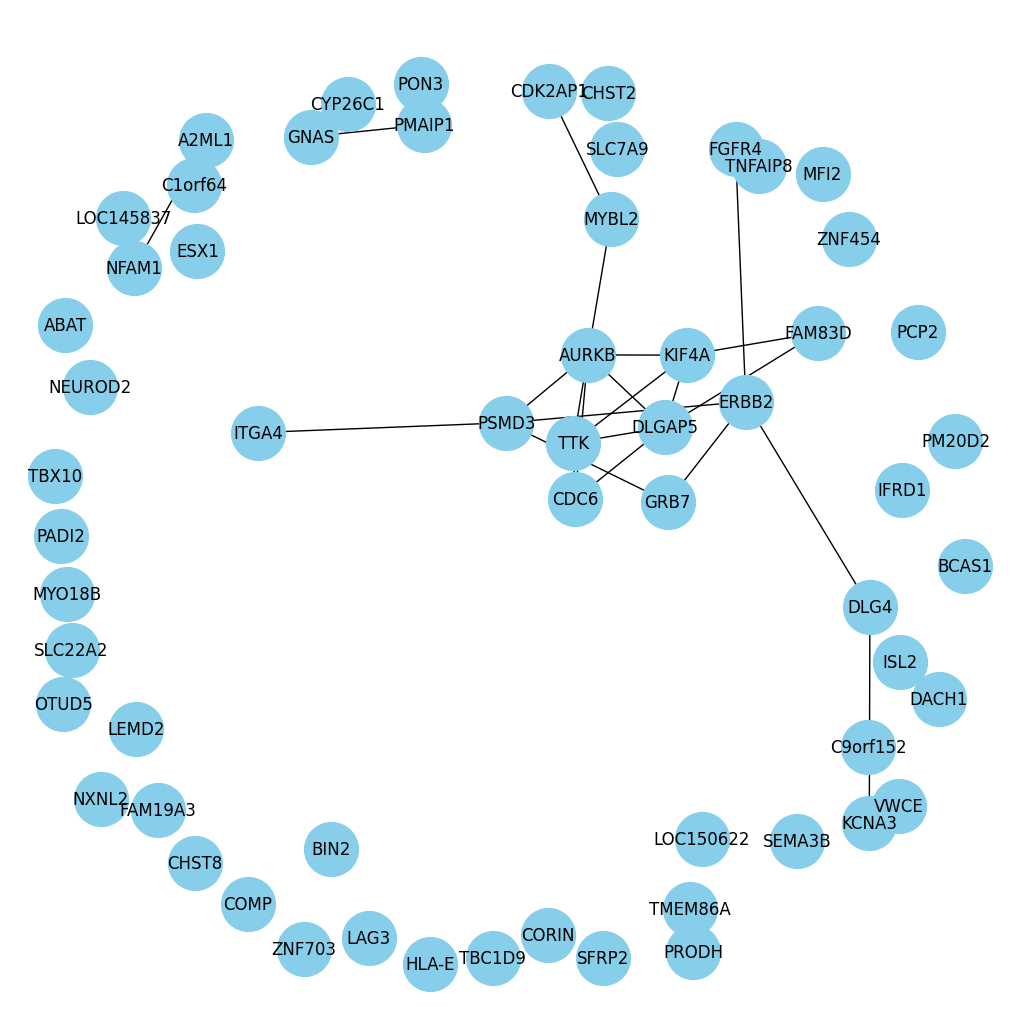

In [100]:
import networkx as nx
import matplotlib.pyplot as plt

from bipartite_gnn.preprocessing import get_interactions

# good_genes = ['LOC150622', 'BCAS1', 'DACH1', 'CDC6', 'ABAT', 'C9orf152', 'AURKB', 'FGFR4', 'A2ML1', 'TMEM86A', 'PCP2', 'FAM19A3', 'PRODH', 'PM20D2', 'PADI2', 'PMAIP1', 'TTK', 'TBX10', 'ZNF703', 'PSMD3', 'C1orf64', 'NXNL2', 'TBC1D9', 'DLGAP5', 'LOC145837', 'KIF4A', 'ERBB2', 'FAM83D', 'MYBL2', 'IFRD1']

A = get_interactions(
    good_genes,
    good_genes,
    interactant1_colname="Official Symbol Interactor A",
    interactant2_colname="Official Symbol Interactor B",
    interact_file="biogrid_preprocessed_data.csv",
    search_both_cols=True,
)

App = get_interactions(
    good_genes,
    good_genes,
    interactant1_colname="gene1",
    interactant2_colname="gene2",
    interact_file="string_db/ppi.csv",
    search_both_cols=True,
)

# remove self connections
for i in range(len(A)):
    A[i, i] = 0
    App[i, i] = 0

A = torch.logical_or(A, App)

A = np.array(A)

# remove genes which dont have any interactions 

# Create a NetworkX graph from the adjacency matrix
G = nx.from_numpy_array(A)

# Add node labels
mapping = {i: gene for i, gene in enumerate(good_genes)}
G = nx.relabel_nodes(G, mapping)

# Draw the graph
pos = nx.spring_layout(G, k=0.6, iterations=50)
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1500, font_size=12)
plt.axis('off')
plt.show()

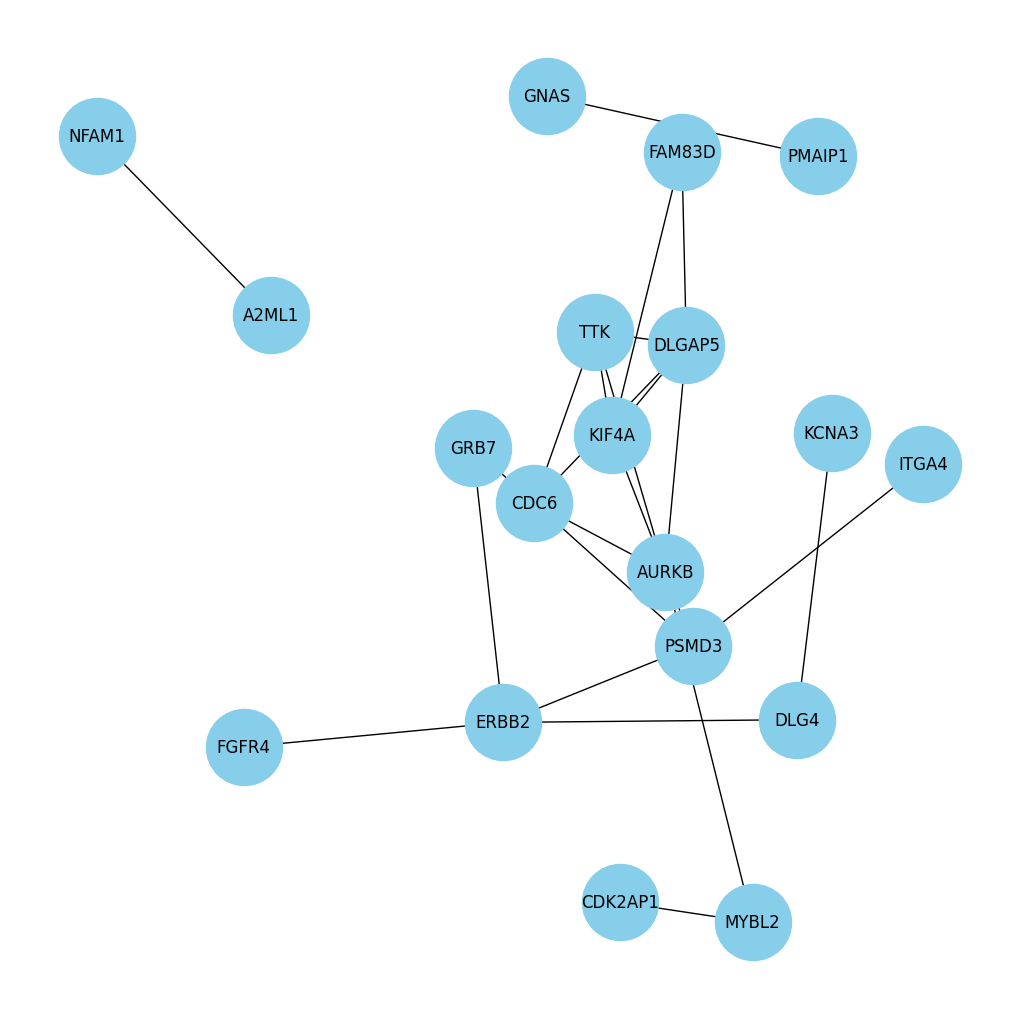

In [101]:
# Create a NetworkX graph from the adjacency matrix
G = nx.from_numpy_array(A)

# Add node labels
mapping = {i: gene for i, gene in enumerate(good_genes)}
G = nx.relabel_nodes(G, mapping)

# Remove genes that don't have any interactions
genes_to_keep = [node for node, degree in G.degree() if degree > 0]
G = G.subgraph(genes_to_keep)

# Draw the graph
pos = nx.spring_layout(G, k=0.3, iterations=10)
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=12)
plt.axis('off')
plt.show()

In [200]:
# good_mirnas = ['hsa-miR-15b-3p', 'hsa-miR-210-3p', 'hsa-miR-101-3p', 'hsa-miR-339-5p', 'hsa-miR-140-5p', 'hsa-miR-452-5p', 'hsa-miR-1307-3p', 'hsa-miR-19b-3p', 'hsa-miR-330-5p', 'hsa-miR-766-3p', 'hsa-miR-93-3p', 'hsa-miR-324-3p', 'hsa-miR-107', 'hsa-miR-4677-3p', 'hsa-miR-532-5p', 'hsa-miR-151a-5p' 'hsa-miR-324-5p', 'hsa-let-7a-3p', 'hsa-miR-29b-3p', 'hsa-miR-25-3p', 'hsa-miR-1307-5p', 'hsa-miR-455-5p', 'hsa-miR-589-5p', 'hsa-miR-584-5p', 'hsa-miR-148a-3p', 'hsa-miR-10a-5p', 'hsa-miR-361-3p', 'hsa-miR-484', 'hsa-miR-146a-5p', 'hsa-miR-625-3p', 'hsa-miR-222-3p']

good_mirnas = ['hsa-miR-15b-3p', 'hsa-miR-210-3p', 'hsa-miR-101-3p', 'hsa-miR-339-5p', 'hsa-miR-140-5p', 'hsa-miR-452-5p', 'hsa-miR-1307-3p', 'hsa-miR-19b-3p', 'hsa-miR-330-5p', 'hsa-miR-766-3p', 'hsa-miR-93-3p', 'hsa-miR-324-3p', 'hsa-miR-107', 'hsa-miR-4677-3p', 'hsa-miR-532-5p', 'hsa-miR-151a-5p', 'hsa-miR-324-5p', 'hsa-let-7a-3p', 'hsa-miR-29b-3p', 'hsa-miR-25-3p', 'hsa-miR-1307-5p', 'hsa-miR-455-5p', 'hsa-miR-589-5p', 'hsa-miR-584-5p', 'hsa-miR-148a-3p', 'hsa-miR-10a-5p', 'hsa-miR-361-3p', 'hsa-miR-484', 'hsa-miR-146a-5p', 'hsa-miR-625-3p', 'hsa-miR-222-3p', 'hsa-miR-505-3p', 'hsa-let-7d-3p', 'hsa-miR-769-5p', 'hsa-miR-339-3p', 'hsa-miR-23a-3p', 'hsa-miR-423-5p', 'hsa-miR-30d-5p', 'hsa-miR-28-3p', 'hsa-miR-497-5p', 'hsa-let-7c-5p', 'hsa-miR-15a-5p', 'hsa-miR-17-5p', 'hsa-miR-99b-5p', 'hsa-miR-221-3p', 'hsa-miR-423-3p', 'hsa-miR-130a-3p', 'hsa-miR-331-3p', 'hsa-miR-15b-5p', 'hsa-miR-24-2-5p', 'hsa-miR-196a-5p', 'hsa-miR-185-5p', 'hsa-miR-21-3p', 'hsa-miR-574-3p', 'hsa-miR-127-3p', 'hsa-miR-148b-3p', 'hsa-miR-539-5p', 'hsa-miR-361-5p', 'hsa-let-7i-3p', 'hsa-miR-342-5p', 'hsa-miR-486-5p', 'hsa-miR-92a-3p', 'hsa-miR-30a-5p', 'hsa-miR-16-5p', 'hsa-miR-338-3p', 'hsa-miR-24-1-5p', 'hsa-miR-744-5p', 'hsa-miR-30c-5p', 'hsa-miR-29c-5p', 'hsa-miR-532-3p', 'hsa-miR-146b-3p', 'hsa-miR-103a-3p', 'hsa-miR-199a-5p', 'hsa-miR-130b-3p', 'hsa-miR-144-5p', 'hsa-let-7b-3p', 'hsa-miR-191-5p', 'hsa-miR-181a-5p', 'hsa-let-7g-5p', 'hsa-miR-196b-5p', 'hsa-miR-375-3p', 'hsa-miR-582-3p', 'hsa-miR-653-5p', 'hsa-miR-378a-3p', 'hsa-miR-3074-5p', 'hsa-miR-181c-3p', 'hsa-miR-141-3p']
good_mirnas = good_mirnas[:60]

A_mrna_mirna = get_interactions(
    good_genes,
    good_mirnas,
    interactant1_colname="gene",
    interactant2_colname="mirna",
    interact_file="mirna_mrna_interactions_DB.csv",
)

len(good_mirnas)

Found 17.0 interactions


60

In [201]:
# remove the last -3p or -5p from the mirna names
good_mirnas = [mirna[:-3] if mirna.endswith("-3p") or mirna.endswith("-5p") else mirna for mirna in good_mirnas]

In [202]:
good_mirnas

['hsa-miR-15b',
 'hsa-miR-210',
 'hsa-miR-101',
 'hsa-miR-339',
 'hsa-miR-140',
 'hsa-miR-452',
 'hsa-miR-1307',
 'hsa-miR-19b',
 'hsa-miR-330',
 'hsa-miR-766',
 'hsa-miR-93',
 'hsa-miR-324',
 'hsa-miR-107',
 'hsa-miR-4677',
 'hsa-miR-532',
 'hsa-miR-151a',
 'hsa-miR-324',
 'hsa-let-7a',
 'hsa-miR-29b',
 'hsa-miR-25',
 'hsa-miR-1307',
 'hsa-miR-455',
 'hsa-miR-589',
 'hsa-miR-584',
 'hsa-miR-148a',
 'hsa-miR-10a',
 'hsa-miR-361',
 'hsa-miR-484',
 'hsa-miR-146a',
 'hsa-miR-625',
 'hsa-miR-222',
 'hsa-miR-505',
 'hsa-let-7d',
 'hsa-miR-769',
 'hsa-miR-339',
 'hsa-miR-23a',
 'hsa-miR-423',
 'hsa-miR-30d',
 'hsa-miR-28',
 'hsa-miR-497',
 'hsa-let-7c',
 'hsa-miR-15a',
 'hsa-miR-17',
 'hsa-miR-99b',
 'hsa-miR-221',
 'hsa-miR-423',
 'hsa-miR-130a',
 'hsa-miR-331',
 'hsa-miR-15b',
 'hsa-miR-24-2',
 'hsa-miR-196a',
 'hsa-miR-185',
 'hsa-miR-21',
 'hsa-miR-574',
 'hsa-miR-127',
 'hsa-miR-148b',
 'hsa-miR-539',
 'hsa-miR-361',
 'hsa-let-7i',
 'hsa-miR-342']

In [103]:
import networkx as nx

# Create a NetworkX graph from the adjacency matrix
G = nx.from_numpy_array(A)

# Add node labels
mapping = {i: gene for i, gene in enumerate(good_genes)}
G = nx.relabel_nodes(G, mapping)

# Create an adjacency list dictionary
adjacency_list = {node: list(G.neighbors(node)) for node in G.nodes()}

# Print the adjacency list
for gene, neighbors in adjacency_list.items():
    print(f"{gene} is connected to: {', '.join(neighbors)}")

LOC150622 is connected to: 
BCAS1 is connected to: 
DACH1 is connected to: 
CDC6 is connected to: AURKB, TTK, DLGAP5
ABAT is connected to: 
C9orf152 is connected to: 
AURKB is connected to: CDC6, TTK, PSMD3, DLGAP5, KIF4A, MYBL2
FGFR4 is connected to: ERBB2
A2ML1 is connected to: NFAM1
TMEM86A is connected to: 
PCP2 is connected to: 
FAM19A3 is connected to: 
PRODH is connected to: 
PM20D2 is connected to: 
PADI2 is connected to: 
PMAIP1 is connected to: GNAS
TTK is connected to: CDC6, AURKB, DLGAP5, KIF4A
TBX10 is connected to: 
ZNF703 is connected to: 
PSMD3 is connected to: AURKB, ERBB2, GRB7, ITGA4
C1orf64 is connected to: 
NXNL2 is connected to: 
TBC1D9 is connected to: 
DLGAP5 is connected to: CDC6, AURKB, TTK, KIF4A, FAM83D
LOC145837 is connected to: 
KIF4A is connected to: AURKB, TTK, DLGAP5, FAM83D
ERBB2 is connected to: FGFR4, PSMD3, GRB7, DLG4
FAM83D is connected to: DLGAP5, KIF4A
MYBL2 is connected to: AURKB, CDK2AP1
IFRD1 is connected to: 
GNAS is connected to: PMAIP1
LAG3

In [81]:
A.shape

(30, 30)

In [82]:
A_mrna_mirna.shape

(30, 30)

In [98]:
A_mrna_mrna.shape

(30, 30)

In [193]:
good_mirnas = ["".join(good_mirnas.split("-")[:-1]) for good_mirnas in good_mirnas]

In [194]:
good_mirnas

['hsamiR15b',
 'hsamiR210',
 'hsamiR101',
 'hsamiR339',
 'hsamiR140',
 'hsamiR452',
 'hsamiR1307',
 'hsamiR19b',
 'hsamiR330',
 'hsamiR766',
 'hsamiR93',
 'hsamiR324',
 'hsamiR',
 'hsamiR4677',
 'hsamiR532',
 'hsamiR151a',
 'hsamiR324',
 'hsalet7a',
 'hsamiR29b',
 'hsamiR25',
 'hsamiR1307',
 'hsamiR455',
 'hsamiR589',
 'hsamiR584',
 'hsamiR148a',
 'hsamiR10a',
 'hsamiR361',
 'hsamiR',
 'hsamiR146a',
 'hsamiR625',
 'hsamiR222',
 'hsamiR505',
 'hsalet7d',
 'hsamiR769',
 'hsamiR339',
 'hsamiR23a',
 'hsamiR423',
 'hsamiR30d',
 'hsamiR28',
 'hsamiR497',
 'hsalet7c',
 'hsamiR15a',
 'hsamiR17',
 'hsamiR99b',
 'hsamiR221',
 'hsamiR423',
 'hsamiR130a',
 'hsamiR331',
 'hsamiR15b',
 'hsamiR242',
 'hsamiR196a',
 'hsamiR185',
 'hsamiR21',
 'hsamiR574',
 'hsamiR127',
 'hsamiR148b',
 'hsamiR539',
 'hsamiR361',
 'hsalet7i',
 'hsamiR342']

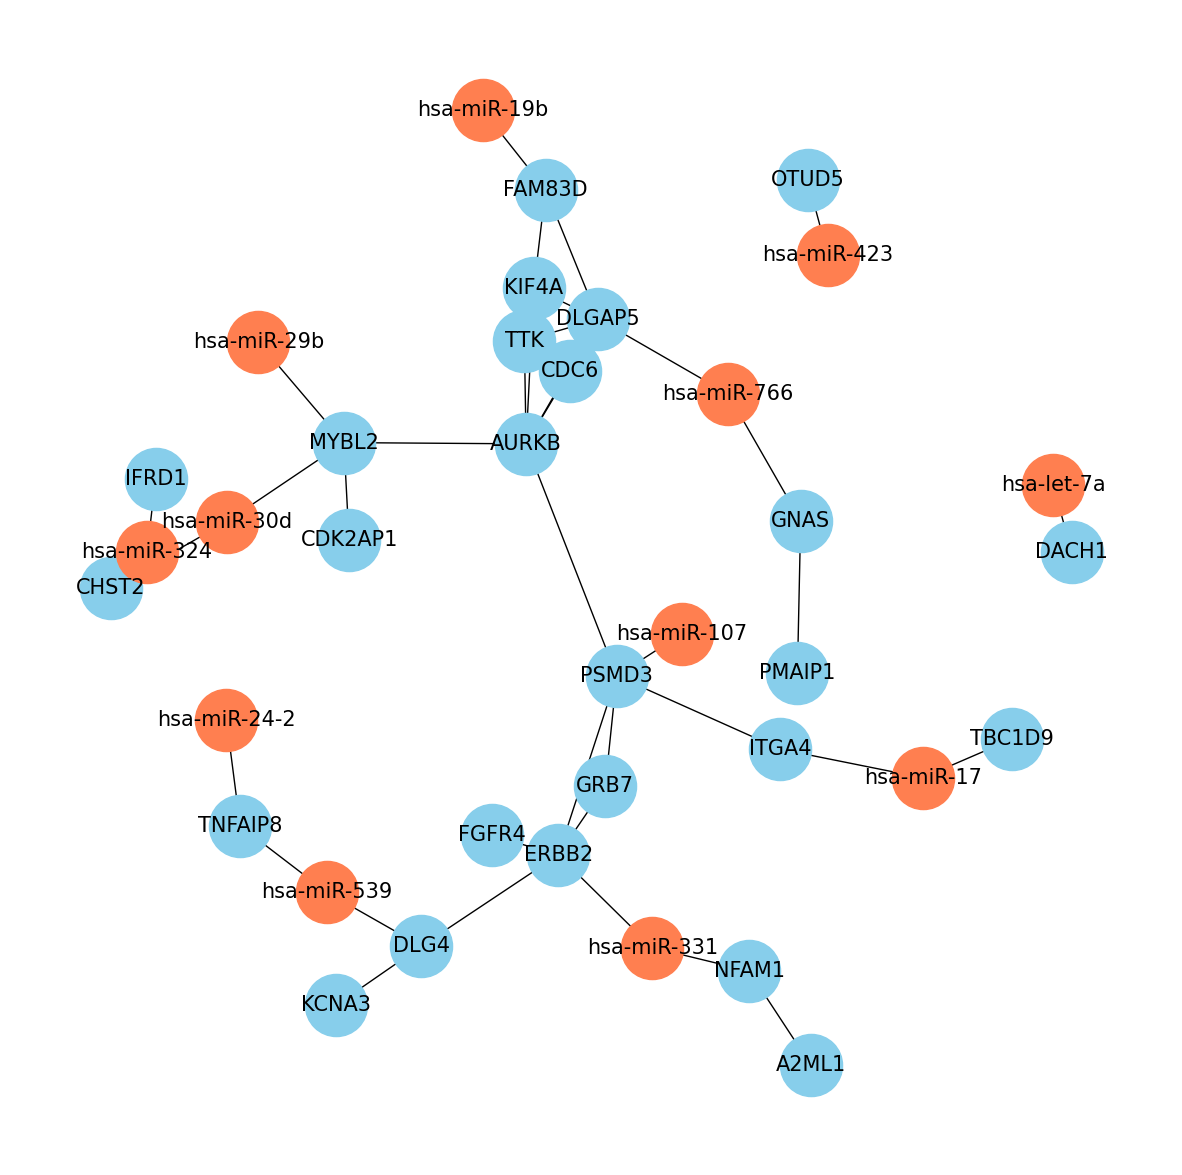

: 

In [289]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create adjacency matrices
A_mrna_mrna = np.array(A)
A_mrna_mirna = np.array(A_mrna_mirna)

B = np.zeros((A_mrna_mrna.shape[0] + A_mrna_mirna.shape[0], A_mrna_mrna.shape[1] + A_mrna_mirna.shape[1]))

B[:A_mrna_mrna.shape[0], :A_mrna_mrna.shape[1]] = A_mrna_mrna

B[:A_mrna_mrna.shape[0], A_mrna_mrna.shape[1]:] = A_mrna_mirna
B[A_mrna_mrna.shape[0]:, :A_mrna_mrna.shape[1]] = A_mrna_mirna.T

# Create a bipartite graph
B = nx.from_numpy_array(B)

# Set node attributes for genes and miRNAs
genes = list(range(len(good_genes)))
mirnas = list(range(len(good_genes), len(good_genes) + len(good_mirnas)))
node_types = {node: 'gene' for node in genes} | {node: 'mirna' for node in mirnas}
node_labels = {i: gene for i, gene in enumerate(good_genes + good_mirnas)}

# Add node labels and node types
nx.set_node_attributes(B, node_types, 'node_type')
B = nx.relabel_nodes(B, node_labels)

# Remove nodes without edges
nodes_to_keep = [node for node, degree in B.degree() if degree > 0]
B = B.subgraph(nodes_to_keep)

# Draw the bipartite graph
pos = nx.spring_layout(B, k=1, iterations=150)
plt.figure(figsize=(15, 15))

# Draw nodes with different colors based on node type
gene_nodes = [node for node, node_type in nx.get_node_attributes(B, 'node_type').items() if node_type == 'gene']
mirna_nodes = [node for node, node_type in nx.get_node_attributes(B, 'node_type').items() if node_type == 'mirna']
nx.draw_networkx_nodes(B, pos, nodelist=gene_nodes, node_color='skyblue', node_size=2000)
nx.draw_networkx_nodes(B, pos, nodelist=mirna_nodes, node_color='coral', node_size=2000)

# Draw edges
nx.draw_networkx_edges(B, pos)

# Draw labels
nx.draw_networkx_labels(B, pos, font_size=15)

plt.axis('off')
plt.show()

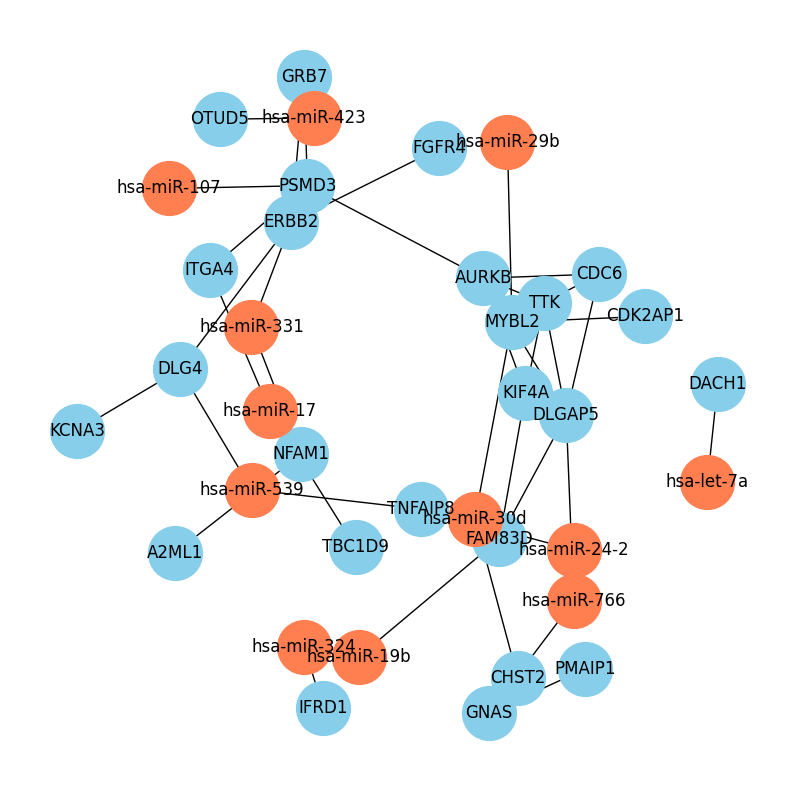

In [209]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create adjacency matrices
A_mrna_mrna = np.array(A)
A_mrna_mirna = np.array(A_mrna_mirna)

# Ensure consistent dimensions
if A_mrna_mrna.shape[1] != A_mrna_mirna.shape[0]:
    A_mrna_mirna = A_mrna_mirna.T

# Create a combined adjacency matrix
B = np.zeros((A_mrna_mrna.shape[0] + A_mrna_mirna.shape[0], A_mrna_mrna.shape[1] + A_mrna_mirna.shape[1]))
B[:A_mrna_mrna.shape[0], :A_mrna_mrna.shape[1]] = A_mrna_mrna
B[:A_mrna_mrna.shape[0], A_mrna_mrna.shape[1]:] = A_mrna_mirna
B[A_mrna_mrna.shape[0]:, :A_mrna_mrna.shape[1]] = A_mrna_mirna.T

# Create a bipartite graph
B = nx.from_numpy_array(B)

# Set node attributes for genes and miRNAs
genes = list(range(len(good_genes)))
mirnas = list(range(len(good_genes), len(good_genes) + len(good_mirnas)))
node_types = {node: 'gene' for node in genes} | {node: 'mirna' for node in mirnas}
node_labels = {i: gene for i, gene in enumerate(good_genes + good_mirnas)}

# Add node labels and node types
nx.set_node_attributes(B, node_types, 'node_type')
B = nx.relabel_nodes(B, node_labels)

# Remove nodes without edges
nodes_to_keep = [node for node, degree in B.degree() if degree > 0]
B = B.subgraph(nodes_to_keep)

# Draw the bipartite graph
pos = nx.spring_layout(B, k=0.6, iterations=50)
plt.figure(figsize=(10, 10))

# Draw nodes with different colors based on node type
gene_nodes = [node for node, node_type in nx.get_node_attributes(B, 'node_type').items() if node_type == 'gene']
mirna_nodes = [node for node, node_type in nx.get_node_attributes(B, 'node_type').items() if node_type == 'mirna']
nx.draw_networkx_nodes(B, pos, nodelist=gene_nodes, node_color='skyblue', node_size=1500)
nx.draw_networkx_nodes(B, pos, nodelist=mirna_nodes, node_color='coral', node_size=1500)

# Draw edges
nx.draw_networkx_edges(B, pos)

# Draw labels
nx.draw_networkx_labels(B, pos, font_size=12)

plt.axis('off')
plt.show()